# Manual Pipeline 2
- In this notebook, I will refactor the manual_pipeline1 processing into a single function.
- I will have an option for autopower or n_points as part of the function.
- Add function that tests for closeness between selected peaks:
    - Consider the LSP resolution.
- Afterwards cluster peaks in the same ranges and choose the strongest like in the priors analysis.

In [9]:
import pandas as pd
from astropy.time import Time
import matplotlib.pyplot as plt
import celerite2
import numpy as np
from celerite2 import terms
from scipy.optimize import minimize
from prettytable import PrettyTable
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks
from scipy.optimize import curve_fit


# Importing data
data = pd.read_csv(r"./Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)

# data = pd.read_csv(r"./Data/hd166_caii.txt", sep='\s',skip_blank_lines=True)
data.columns = ["JD", "sind"]
data['JD'] = data['JD'] + 2400000.0 # this file drops the 24 prefix
time_obj = Time(data["JD"].to_numpy(), format='jd', scale='tdb')
data["year"] = time_obj.jyear
data["day"] = time_obj.jd 
data['datetime'] = time_obj.to_datetime(timezone=None)
data = data.set_index('datetime')

# No need to down sample the dataset here. yay!
def split_df(df, train_split=0.8, valid_split=0.19):
    n = len(df)
    train_idx = round(train_split * n)
    valid_idx = round((train_split + valid_split) * n)
    return df.iloc[:train_idx].copy(), df.iloc[train_idx:valid_idx].copy(), df.iloc[valid_idx:].copy()

# Split the data
train_df, valid_df, test_df = split_df(data)


C:\Users\Joey\AppData\Local\Temp\ipykernel_22712\3617134450.py:15: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(r"./Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)


In [10]:
def check_aliases(freq, accepted_freqs, tol = 0.05):
    '''
    Check if a single period is an alias.
    If it is an alias we can skip it and use the next period as dominant.
    Aliases are not subtracted: they are noise.
    If True, signal is not an alias so set it be added.
    '''
    accepted_periods = 1/np.array(accepted_freqs)
    for p in accepted_periods:
        for mult in [0.25, 1/3, 0.5, 1, 2, 3, 4]:
            pmult_freq = 1/(p*mult)
            delta = np.abs((freq - pmult_freq)/freq)
            if delta < tol: # The signal is an alias
                return False, p, mult, delta
    return True, None, None, None

def check_windows(freq, tol = 0.05):
    '''
    Checks if a signal looks suspiciously like a window function.
    If True, signal is not a window as defined.
    '''
    year = 365.25
    month = year /12
    week = 7
    windows = [year, year/2, year/3, year/4, month, 2*month, week, 2* week, 3 * week, 29.5] #29.5 is lunar
    for window in windows:
        window_freq = 1/np.array(window)
        delta = np.abs((freq-window_freq)/freq)
        if delta < tol: # Then we classify the signal as a window function
            return False, window, delta
    return True, None, None



In [11]:
# Helpers for performing the SNR checks
def gaussian(t, A, mu, std, c):
    return A * np.exp(-0.5 * ((t - mu) / std)**2) + c

def find_snr(powers, freqs, peak_freq, peak_idx, peak_height, window = 150):
    '''
    Fits a Gaussian around a peak, subtracts that peak Gaussian, and then compares it to the remaining residual noise.
    '''
    # Define a window around the peak to which to fit a Gaussian
    n = len(powers)
    left  = max(0, peak_idx - window)
    right = min(n, peak_idx + window + 1)
    window_freqs = freqs[left:right]
    window_powers = powers[left:right]
    minf = min(window_freqs)
    maxf = max(window_freqs)

    # Define initial guesses for the fit
    A0 = peak_height
    mu0 = peak_freq
    std0 = mu0 * 0.1 #FWHM is a bit overkill
    c0 = np.median(window_powers)
    p0 = [A0, mu0, std0, c0]

    # Try the curve fit
    try:
        popt, _ = curve_fit(gaussian, window_freqs, window_powers,
                        p0 = p0,
                        bounds = ([0, minf, 0, 0], [np.inf, maxf, np.inf, np.inf]))
        resid_lsp = window_powers - gaussian(window_freqs, *popt)
        noise_std = np.std(resid_lsp)
        snr = popt[0] / noise_std # popt[0] is the A[0]
        return snr, popt, resid_lsp
    except (RuntimeError, ValueError):
        noise = np.mean(window_powers)
        return A0/noise, None, None


In [12]:
# Now do the simultneous fit based on all the accepted periods
# def build_design_matrix(t, accepted_freqs):
#     cols = [np.ones(len(t))]
#     for p in accepted_periods:
#         cols.append(np.cos(2 * np.pi * t * p))
#         cols.append(np.sin(2 * np.pi * t * p))
#     return np.column_stack(cols)

# def simultaneous_fit(t, y, accepted_freqs):
#     X = build_design_matrix(t, accepted_freqs)
#     params, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
#     fitted = X @ params
#     residuals = y - fitted
#     return residuals, params
def build_design_matrix(t, accepted_freqs):
    """
    Constructs the design matrix for a linear least-squares fit
    of multiple sine/cosine pairs (plus a constant offset).
    """
    # Start with a column of ones for the offset (DC component)
    cols = [np.ones(len(t))]
    
    for f in accepted_freqs:
        # Math: 2 * pi * frequency * time
        # This is equivalent to (2 * pi * t) / period
        cols.append(np.cos(2 * np.pi * f * t))
        cols.append(np.sin(2 * np.pi * f * t))
        
    return np.column_stack(cols)

def simultaneous_fit(t, y, accepted_freqs):
    """
    Fits all identified frequencies simultaneously and returns 
    the residuals for the next iteration of the LSP.
    """
    if not accepted_freqs:
        # If no frequencies yet, residuals are just the original data
        return y, np.array([np.mean(y)])

    # 1. Build the matrix
    X = build_design_matrix(t, accepted_freqs)
    
    # 2. Solve the linear system: X * params = y
    # np.linalg.lstsq is robust for this kind of overdetermined system
    params, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    
    # 3. Calculate the model and the residuals
    fitted_model = X @ params
    residuals = y - fitted_model
    
    return residuals, params

In [13]:
def set_period_axes(ax, ylabel='Normalised Power'):
    ax2 = ax.secondary_xaxis('top', functions=(lambda d: d / 365.25, lambda y: y * 365.25))
    ax2.set_xlabel('Period (years)')
    ax.set_xlabel('Period (days)')
    ax.set_ylabel(ylabel)

In iteration 0, period at 2993.39 days was accepted.


TypeError: 'Axes' object is not subscriptable

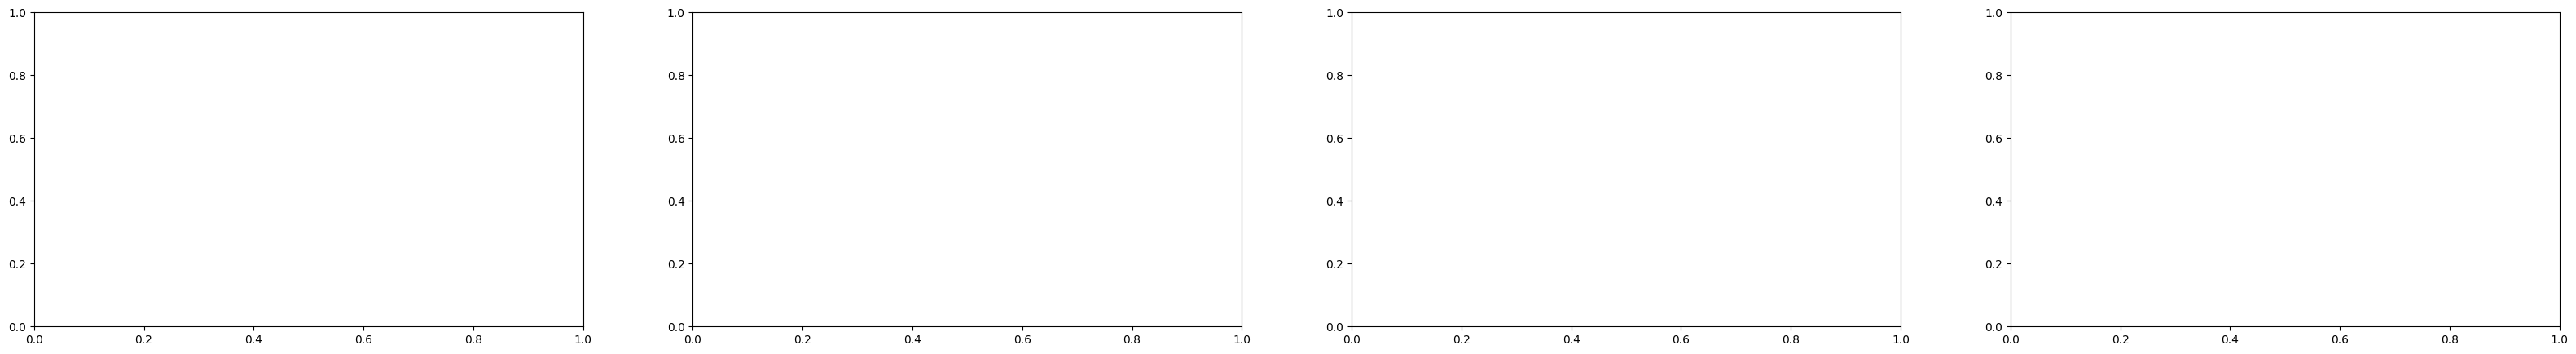

In [ ]:
def fit_peaks(df,
            manual_freq = None, period_range = [0.1, 100*365], n_periods = 10000, 
            FAPs = [10,5,1,0.1], key_FAP_idx = -1, 
            threshold = 4,
            plot = True):
    '''
    Iteratively finds the peaks of the LSP.
    This will be used in the prior selsection process.
    Finds one peak then checks if it is an alias or a window.
    Also checks if it is too similar to a previous peak for the LSP to have resolved.
    If that peak also satiesfies an SNR threshold, add it to an accepted periods list.

    df is the dataframe being processed (training set)
    manual_freq True means the period_range and n_periods defines the set of periods calculated.
    Period_range is in days

    Returns a list of accepted periods.
    '''
    accepted_peak_freqs = [] # We will work in frequency space for the analysis other than for the plotting. It is easier for the SNR fitting.
    accepted_peak_heights = [] # The concomitant power heights

    if manual_freq == 'linear':
        min_period = period_range[0]
        max_period = period_range[1]
        periods = np.linspace(min_period, max_period, n_periods)
        freqs = 1 / periods
    if manual_freq == 'log':
        min_period = period_range[0]
        max_period = period_range[1]
        periods = np.logspace(np.log10(min_period), np.log10(max_period), n_periods)
        freqs = 1 / periods
    
    resids = [df['sind']]
    iter_powers = [] # Add the LSPs here
    iter_params = [] # Parameters of the simultaneous fit
    iter_peaks = [] # the full list of peaks found at each stage
    iter_invFAPs = [] # the list of powers corresponding to the FAPs
     
    i = 0 # What index in resids we are presently processing
    t = df['day'] # Fixed time axis for al

    # Now calculate the FAPs
    FAPs = np.array(FAPs)/100

    while True:
        # Take the LSP : powers for the freqs
        ls = LombScargle(t, resids[i])
        if manual_freq is None: # Use autopower
            freqs, powers = ls.autopower(normalization = 'psd')
            periods = 1/freqs
        else:
            powers = ls.power(freqs, normalization = 'psd')

        power_invFAPs = ls.false_alarm_level(FAPs, method = 'bootstrap') 
        key_FAP = float(power_invFAPs[key_FAP_idx])
        # Identify FAPs above the key FAP
        peak_idxs, properties = find_peaks(powers, height=key_FAP) # peaks is an array of the indices of the input arrays with the peaks
        peak_freqs = freqs[peak_idxs]
        peak_heights = properties['peak_heights']

        # Break if none
        if len(peak_freqs) == 0:
            break

        # Sort identified peaks by height
        sort_idx = np.argsort(peak_heights)[::-1]
        peak_freqs = peak_freqs[sort_idx]
        peak_heights = peak_heights[sort_idx] 
        peak_idxs = peak_idxs[sort_idx]

        found = False
        # Loop through peaks until one satisfies conditions or the end is reached
        for peak_freq, peak_height, peak_idx in zip(peak_freqs, peak_heights, peak_idxs):
            alias_cond, p, mult, delta = check_aliases(freq = peak_freq, accepted_freqs= accepted_peak_freqs)
            if alias_cond == False: # This is an alias; skip freq
                print(f"Peak at period {1/peak_freq:.2f} was identified to be an alias of {p:.2f} days at mult {mult:.2f} by tolerance {delta:.2f}.")

            else: # Not an alias; now check window
                window_cond, window, delta = check_windows(freq = peak_freq)
                if window_cond == False: # This is a window function; skip freq
                    print(f"Peak at period {1/peak_freq:.2f} was identified to be a window of {window:.2f} days by tolerance {delta:.2f}.")
                
                else: # Not a window; now check SNR
                    snr, popt, resid_lsr =  find_snr(powers, freqs, peak_freq, peak_idx, peak_height, window = 150)
                    if resid_lsr is None:
                        print("SNR failed to fit Gaussian. Fell back to height vs average.")

                    if snr > threshold: # All checks passed. Append
                        accepted_peak_freqs.append(peak_freq) # Freq, height
                        accepted_peak_heights.append(peak_height)
                        found = True # indicates that we have added a frequency this time
                        print(f"In iteration {i}, period at {1/peak_freq:.2f} days was accepted.")
                        break # stops searching freqs
                    
                    else: # Go to nest frequency
                        pass
        
        # if we have not found a frequency, this means that we have reached the FAP limit
        if found == False:
            break # Leaves the while True loop
        
        else: # freq found now do the refitting for the next loop round
            resid, params = simultaneous_fit(df['day'], df['sind'], accepted_peak_freqs)
            resids.append(resid)
            iter_powers.append(powers) # The LSPs for plotting
            iter_params.append(params)
            iter_peaks.append(peak_freqs)
            iter_invFAPs.append(power_invFAPs)
            i += 1 # Now the cycle repeats with the new set of resids

    periods = 1/freqs

    # Now we have a list of freqs: plot and return
    n_iter = len(resids)-1 # how many iterations we completed 
    if plot:
        fig, ax =  plt.subplots(n_iter, 4, figsize = (10*4,5*n_iter))
        for row in range(0,n_iter):
            # Plot LSP for each iteration
            ax[row][0].set_xscale('log')
            ax[row][0].plot(periods, iter_powers[row])
            set_period_axes(ax[row][0])



    
        
fit_peaks(df = train_df, manual_freq='linear')
    
    
    



In [ ]:
df=train_df
manual_freq = 'linear'
period_range = [0.1, 20*365]
n_periods = 10000
FAPs = [10,5,1,0.1]
key_FAP_idx = -1
threshold = 4
plot = True

accepted_peak_freqs = [] # We will work in frequency space for the analysis other than for the plotting. It is easier for the SNR fitting.
accepted_peak_heights = [] # The concomitant power heights

if manual_freq == 'linear':
    min_period = period_range[0]
    max_period = period_range[1]
    periods = np.linspace(min_period, max_period, n_periods)
    freqs = 1 / periods
if manual_freq == 'log':
    min_period = period_range[0]
    max_period = period_range[1]
    periods = np.logspace(np.log10(min_period), np.log10(max_period), n_periods)
    freqs = 1 / periods

resids = [df['sind']]
iter_powers = [] # Add the LSPs here
iter_params = [] # Parameters of the simultaneous fit
iter_peaks = [] # the full list of peaks found at each stage
iter_invFAPs = [] # the list of powers corresponding to the FAPs
    
i = 0 # What index in resids we are presently processing
t = df['day'] # Fixed time axis for al

# Now calculate the FAPs
FAPs = np.array(FAPs)/100


# Take the LSP : powers for the freqs
ls = LombScargle(t, resids[i])
if manual_freq is None: # Use autopower
    freqs, powers = ls.autopower(normalization = 'psd')
    periods = 1/freqs
else:
    powers = ls.power(freqs, normalization = 'psd')

power_invFAPs = ls.false_alarm_level(FAPs, method = 'bootstrap') 
key_FAP = float(power_invFAPs[key_FAP_idx])
# Identify FAPs above the key FAP
peak_idxs, properties = find_peaks(powers, height=key_FAP) # peaks is an array of the indices of the input arrays with the peaks
peak_freqs = freqs[peak_idxs]
peak_heights = properties['peak_heights']

# Break if none
if len(peak_freqs) == 0:
    print("NO PEAKS")

# Sort identified peaks by height
sort_idx = np.argsort(peak_heights)[::-1]
peak_freqs = peak_freqs[sort_idx]
peak_heights = peak_heights[sort_idx] 
peak_idxs = peak_idxs[sort_idx]

found = False
# Loop through peaks until one satisfies conditions or the end is reached
for peak_freq, peak_height, peak_idx in zip(peak_freqs, peak_heights, peak_idxs):
    alias_cond, p, mult, delta = check_aliases(freq = peak_freq, accepted_freqs= accepted_peak_freqs)
    if alias_cond == False: # This is an alias; skip freq
        print(f"Peak at period {1/peak_freq:.2f} was identified to be an alias of {p:.2f} days at mult {mult:.2f} by tolerance {delta:.2f}.")

    else: # Not an alias; now check window
        window_cond, window, delta = check_windows(freq = peak_freq)
        if window_cond == False: # This is a window function; skip freq
            print(f"Peak at period {1/peak_freq:.2f} was identified to be a window of {window:.2f} days by tolerance {delta:.2f}.")
        
        else: # Not a window; now check SNR
            snr, popt, resid_lsr =  find_snr(powers, freqs, peak_freq, peak_idx, peak_height, window = 150)
            if resid_lsr is None:
                print("SNR failed to fit Gaussian. Fell back to height vs average.")

            if snr > threshold: # All checks passed. Append
                accepted_peak_freqs.append(peak_freq) # Freq, height
                accepted_peak_heights.append(peak_height)
                found = True # indicates that we have added a frequency this time
                print(f"In iteration {i}, period at {1/peak_freq:.2f} days was accepted.")

            
            else: # Go to nest frequency
                pass



resid, params = simultaneous_fit(df['day'], df['sind'], accepted_peak_freqs)
resids.append(resid)
iter_powers.append(powers) # The LSPs for plotting
iter_params.append(params)
iter_peaks.append(peak_freqs)
iter_invFAPs.append(power_invFAPs)

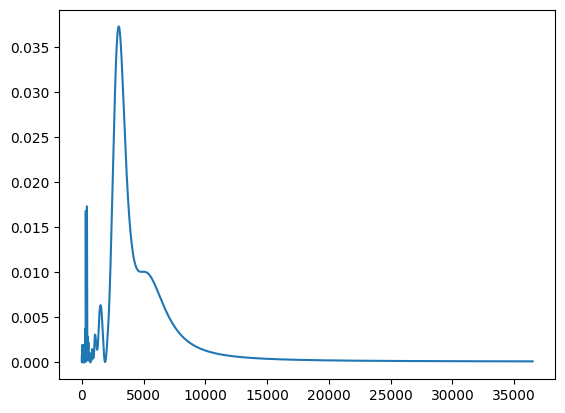

In [28]:
# len(resids), iter_params, iter_pe
len(iter_powers)
plt.plot(periods,iter_powers[0])

In [32]:
i = 1
# Take the LSP : powers for the freqs
ls = LombScargle(t, resids[i])
if manual_freq is None: # Use autopower
    freqs, powers = ls.autopower(normalization = 'psd')
    periods = 1/freqs
else:
    powers = ls.power(freqs, normalization = 'psd')

power_invFAPs = ls.false_alarm_level(FAPs, method = 'bootstrap') 
key_FAP = float(power_invFAPs[key_FAP_idx])
# Identify FAPs above the key FAP
peak_idxs, properties = find_peaks(powers, height=key_FAP) # peaks is an array of the indices of the input arrays with the peaks
peak_freqs = freqs[peak_idxs]
peak_heights = properties['peak_heights']

# Break if none
if len(peak_freqs) == 0:
    print("NO PEAKS")

# Sort identified peaks by height
sort_idx = np.argsort(peak_heights)[::-1]
peak_freqs = peak_freqs[sort_idx]
peak_heights = peak_heights[sort_idx] 
peak_idxs = peak_idxs[sort_idx]

found = False
# Loop through peaks until one satisfies conditions or the end is reached
for peak_freq, peak_height, peak_idx in zip(peak_freqs, peak_heights, peak_idxs):
    alias_cond, p, mult, delta = check_aliases(freq = peak_freq, accepted_freqs= accepted_peak_freqs)
    if alias_cond == False: # This is an alias; skip freq
        print(f"Peak at period {1/peak_freq:.2f} was identified to be an alias of {p:.2f} days at mult {mult:.2f} by tolerance {delta:.2f}.")

    else: # Not an alias; now check window
        window_cond, window, delta = check_windows(freq = peak_freq)
        if window_cond == False: # This is a window function; skip freq
            print(f"Peak at period {1/peak_freq:.2f} was identified to be a window of {window:.2f} days by tolerance {delta:.2f}.")
        
        else: # Not a window; now check SNR
            snr, popt, resid_lsr =  find_snr(powers, freqs, peak_freq, peak_idx, peak_height, window = 150)
            if resid_lsr is None:
                print("SNR failed to fit Gaussian. Fell back to height vs average.")

            if snr > threshold: # All checks passed. Append
                accepted_peak_freqs.append(peak_freq) # Freq, height
                accepted_peak_heights.append(peak_height)
                found = True # indicates that we have added a frequency this time
                print(f"In iteration {i}, period at {1/peak_freq:.2f} days was accepted.")

            
            else: # Go to nest frequency
                pass



resid, params = simultaneous_fit(df['day'], df['sind'], accepted_peak_freqs)
resids.append(resid)
iter_powers.append(powers) # The LSPs for plotting
iter_params.append(params)
iter_peaks.append(peak_freqs)
iter_invFAPs.append(power_invFAPs)
i += 1 # Now the cycle repeats with the new set of resids

NO PEAKS


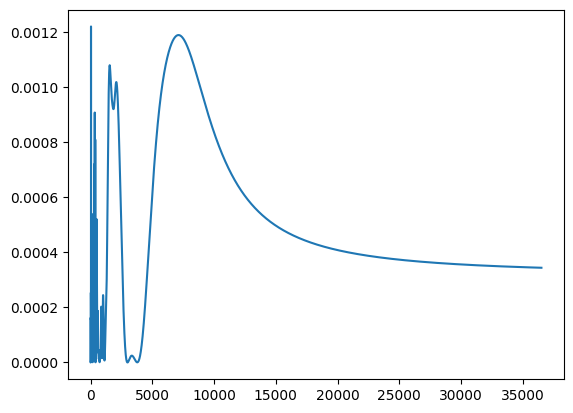

In [33]:
# len(resids), iter_params, iter_pe
len(iter_powers)
plt.plot(periods,iter_powers[1])